
# HW2
## Mahan Fallahpour
## 810802083


<hr style="border: 2px solid black;">


# Q1:


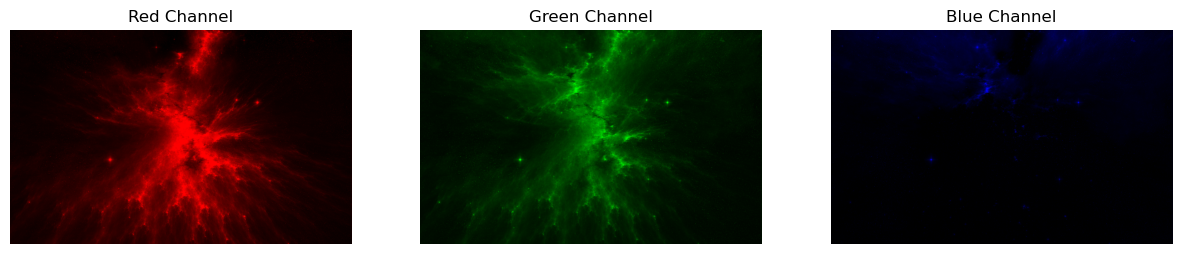

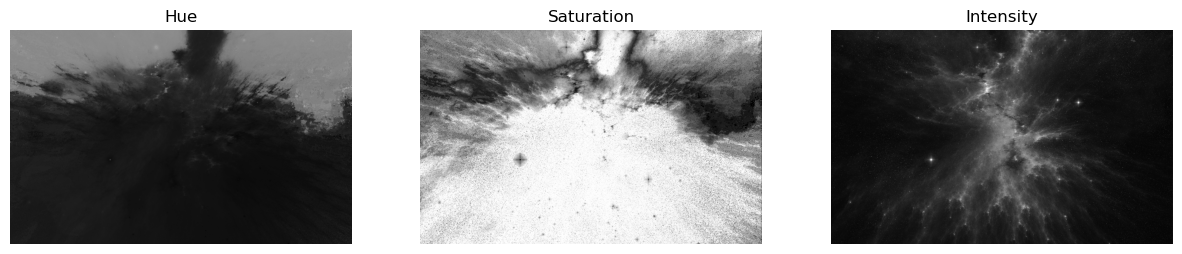

In [8]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('q1/image.jpg')
img_arr = np.array(img, dtype=np.float64)

R = img_arr[:, :, 0]
G = img_arr[:, :, 1]
B = img_arr[:, :, 2]

R_color = np.zeros_like(img_arr, dtype=np.uint8)
R_color[:, :, 0] = R.astype(np.uint8)

G_color = np.zeros_like(img_arr, dtype=np.uint8)
G_color[:, :, 1] = G.astype(np.uint8)

B_color = np.zeros_like(img_arr, dtype=np.uint8)
B_color[:, :, 2] = B.astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(R_color)
plt.title('Red Channel')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(G_color)
plt.title('Green Channel')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(B_color)
plt.title('Blue Channel')
plt.axis('off')
plt.show()

r = R / 255.0
g = G / 255.0
b = B / 255.0

eps = 1e-6
num = 0.5 * ((r - g) + (r - b))
den = np.sqrt((r - g)**2 + (r - b)*(g - b)) + eps
theta = np.arccos(np.clip(num / den, -1.0, 1.0))

H = theta.copy()
H[b > g] = 2 * np.pi - H[b > g]
H = H / (2 * np.pi)

sum_rgb = r + g + b + eps
min_rgb = np.minimum(np.minimum(r, g), b)
S = 1.0 - (3.0 / sum_rgb) * min_rgb

I = (r + g + b) / 3.0

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(H, cmap='gray')
plt.title('Hue')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(S, cmap='gray')
plt.title('Saturation')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(I, cmap='gray')
plt.title('Intensity')
plt.axis('off')
plt.show()

Image.fromarray(R_color).save('q1/Red_Channel.png')
Image.fromarray(G_color).save('q1/Green_Channel.png')
Image.fromarray(B_color).save('q1/Blue_Channel.png')
Image.fromarray((H * 255).astype(np.uint8)).save('q1/Hue_Channel.png')
Image.fromarray((S * 255).astype(np.uint8)).save('q1/Saturation_Channel.png')
Image.fromarray((I * 255).astype(np.uint8)).save('q1/Intensity_Channel.png')



<hr style="border: 2px solid black;">

# Q2:



# First method:

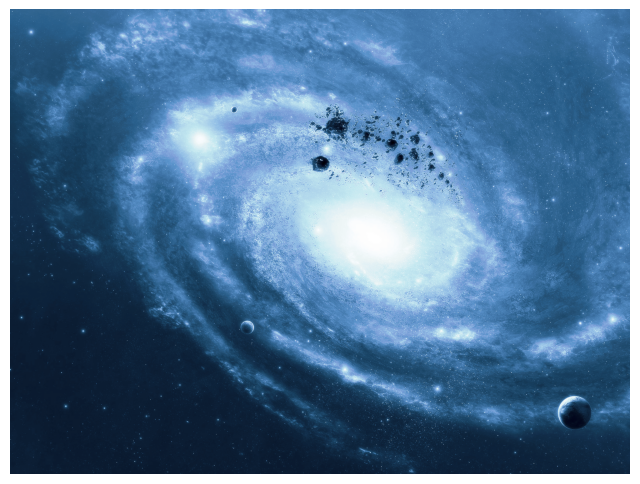

In [7]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def load_image(path):
    return np.array(Image.open(path))

gray_target = load_image('q2/grayscale.png')
if len(gray_target.shape) == 3:
    gray_target = np.mean(gray_target, axis=2).astype(np.uint8)

refs = [load_image('q2/ref1.jpg'), load_image('q2/ref2.jpg'), load_image('q2/ref3.jpg')]

color_map = np.zeros((256, 3), dtype=np.float64)
count_map = np.zeros(256, dtype=np.float64)

for ref in refs:
    if len(ref.shape) == 3:
        r, g, b = ref[:,:,0], ref[:,:,1], ref[:,:,2]
        gray_ref = (0.299 * r + 0.587 * g + 0.114 * b).astype(np.int32)
        
        for i in range(256):
            mask = (gray_ref == i)
            count = np.sum(mask)
            if count > 0:
                color_map[i, 0] += np.sum(r[mask])
                color_map[i, 1] += np.sum(g[mask])
                color_map[i, 2] += np.sum(b[mask])
                count_map[i] += count

for i in range(256):
    if count_map[i] > 0:
        color_map[i] /= count_map[i]

for i in range(256):
    if count_map[i] == 0:
        valid_indices = np.where(count_map > 0)[0]
        if len(valid_indices) > 0:
            nearest_idx = valid_indices[np.argmin(np.abs(valid_indices - i))]
            color_map[i] = color_map[nearest_idx]

output_img = np.zeros((gray_target.shape[0], gray_target.shape[1], 3), dtype=np.uint8)
output_img[:, :, 0] = color_map[gray_target, 0]
output_img[:, :, 1] = color_map[gray_target, 1]
output_img[:, :, 2] = color_map[gray_target, 2]

Image.fromarray(output_img).save('q2/colorized_output.jpg')
plt.figure(figsize=(8, 8))
plt.imshow(output_img)
plt.axis('off')
plt.show()


# second method:


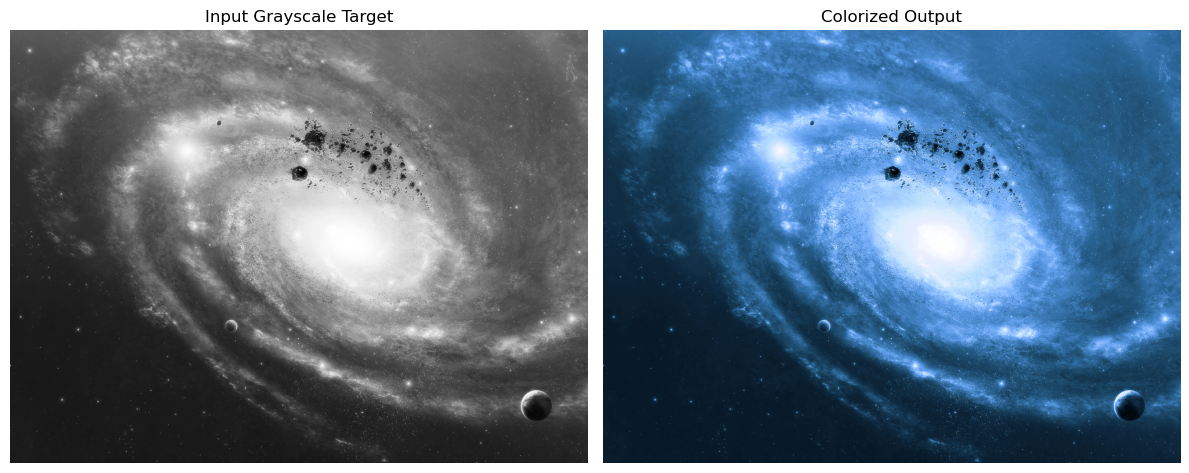

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def load_image(path, mode):
    return np.array(Image.open(path).convert(mode)) / 255.0

gray_img = load_image('q2/grayscale.png', 'L')
ref1 = load_image('q2/ref1.jpg', 'RGB')
ref2 = load_image('q2/ref2.jpg', 'RGB')
ref3 = load_image('q2/ref3.jpg', 'RGB')

def rgb_to_hsi(img):
    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]
    
    I = (R + G + B) / 3.0
    
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B)*(G - B)) + 1e-8
    theta = np.arccos(np.clip(num / den, -1.0, 1.0))
    
    H = np.copy(theta)
    H[B > G] = 2 * np.pi - H[B > G]
    
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = 1.0 - (3.0 / (R + G + B + 1e-8)) * min_rgb
    
    return H, S, I

def hsi_to_rgb(H, S, I):
    R = np.zeros_like(I)
    G = np.zeros_like(I)
    B = np.zeros_like(I)
    
    H_deg = H * (180.0 / np.pi)
    
    m1 = (H_deg >= 0) & (H_deg < 120)
    B[m1] = I[m1] * (1 - S[m1])
    R[m1] = I[m1] * (1 + (S[m1] * np.cos(H[m1])) / np.cos(np.pi/3.0 - H[m1]))
    G[m1] = 3 * I[m1] - (R[m1] + B[m1])
    
    m2 = (H_deg >= 120) & (H_deg < 240)
    H2 = H[m2] - (2 * np.pi / 3.0)
    R[m2] = I[m2] * (1 - S[m2])
    G[m2] = I[m2] * (1 + (S[m2] * np.cos(H2)) / np.cos(np.pi/3.0 - H2))
    B[m2] = 3 * I[m2] - (R[m2] + G[m2])
    
    m3 = (H_deg >= 240) & (H_deg <= 360)
    H3 = H[m3] - (4 * np.pi / 3.0)
    G[m3] = I[m3] * (1 - S[m3])
    B[m3] = I[m3] * (1 + (S[m3] * np.cos(H3)) / np.cos(np.pi/3.0 - H3))
    R[m3] = 3 * I[m3] - (G[m3] + B[m3])
    
    rgb = np.stack([R, G, B], axis=-1)
    return np.clip(rgb, 0, 1)

H_all, S_all, I_all = [], [], []

for ref_img in [ref1, ref2, ref3]:
    h, s, i = rgb_to_hsi(ref_img)
    H_all.append(h.flatten())
    S_all.append(s.flatten())
    I_all.append(np.clip(i.flatten() * 255, 0, 255).astype(int))

H_all = np.concatenate(H_all)
S_all = np.concatenate(S_all)
I_all = np.concatenate(I_all)

h_map = np.zeros(256)
s_map = np.zeros(256)

for i in range(256):
    mask = (I_all == i)
    if np.any(mask):
        h_map[i] = np.mean(H_all[mask])
        s_map[i] = np.mean(S_all[mask])
    else:
        if i > 0:
            h_map[i] = h_map[i-1]
            s_map[i] = s_map[i-1]

gray_8bit = np.clip(gray_img * 255, 0, 255).astype(int)

H_target = h_map[gray_8bit]
S_target = s_map[gray_8bit]
I_target = gray_img

colorized_rgb = hsi_to_rgb(H_target, S_target, I_target)

output_image = Image.fromarray((colorized_rgb * 255).astype(np.uint8))
output_image.save('q2/colorized2_hsi_output.jpg')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Input Grayscale Target")
axes[0].axis('off')

axes[1].imshow(colorized_rgb)
axes[1].set_title("Colorized Output")
axes[1].axis('off')

plt.tight_layout()
plt.show()


<hr style="border: 2px solid black;">

# Q3:

In [3]:
import numpy as np
import cv2

def calculate_psnr_manual(img1, img2):
    if img1.shape != img2.shape:
        raise ValueError("Images have different shapes")
        
    img1_float = img1.astype(np.float64)
    img2_float = img2.astype(np.float64)
    
    mse = np.mean((img1_float - img2_float) ** 2)
    
    if mse == 0:
        return float('inf')
        
    max_pixel = 255.0
    psnr_value = 10.0 * np.log10((max_pixel ** 2) / mse)
    
    return psnr_value

original_img = cv2.imread("q3/q3.jpg")
distorted_img = cv2.imread("q3/q3_noisy.jpg")

manual_result = calculate_psnr_manual(original_img, distorted_img)

cv2_result = cv2.PSNR(original_img, distorted_img)

print(f"Manual PSNR: {manual_result:.4f} dB")
print(f"CV2 PSNR:    {cv2_result:.4f} dB")

Manual PSNR: 18.5530 dB
CV2 PSNR:    18.5530 dB


<hr style="border: 2px solid black;">

# Q4:

PSNR (Noisy vs Reference): 15.2282 dB
PSNR (Reconstructed vs Reference): 18.1412 dB


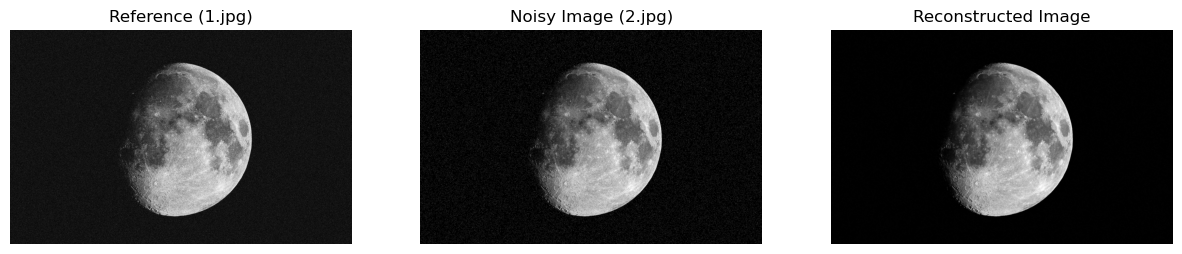

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def calculate_psnr_manual(img1, img2):
    img1_float = img1.astype(np.float64)
    img2_float = img2.astype(np.float64)
    
    mse = np.mean((img1_float - img2_float) ** 2)
    
    if mse == 0:
        return float('inf')
        
    return 10.0 * np.log10((255.0 ** 2) / mse)

def apply_fast_median_filter(img, kernel_size=3):
    pad = kernel_size // 2
    padded_img = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    
    h, w, c = img.shape
    patches = np.zeros((h, w, c, kernel_size * kernel_size), dtype=img.dtype)
    
    idx = 0
    for i in range(kernel_size):
        for j in range(kernel_size):
            patches[:, :, :, idx] = padded_img[i:i+h, j:j+w, :]
            idx += 1
            
    filtered_img = np.median(patches, axis=3).astype(img.dtype)
    return filtered_img

reference_image = cv2.imread("q4/1.jpg")
noisy_image = cv2.imread("q4/2.jpg")

if reference_image is None or noisy_image is None:
    print("Error: One or both images could not be loaded. Check file paths!")
else:
    reconstructed_image = apply_fast_median_filter(noisy_image, kernel_size=3)
    
    cv2.imwrite("q4/reconstructed_q4.jpg", reconstructed_image)

    psnr_noisy = calculate_psnr_manual(reference_image, noisy_image)
    psnr_reconstructed = calculate_psnr_manual(reference_image, reconstructed_image)

    print(f"PSNR (Noisy vs Reference): {psnr_noisy:.4f} dB")
    print(f"PSNR (Reconstructed vs Reference): {psnr_reconstructed:.4f} dB")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(cv2.cvtColor(reference_image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Reference (1.jpg)")
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Noisy Image (2.jpg)")
    axes[1].axis("off")

    axes[2].imshow(cv2.cvtColor(reconstructed_image, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Reconstructed Image")
    axes[2].axis("off")

    plt.show()

<hr style="border: 2px solid black;">

# Q5:

In [5]:
import numpy as np

D = np.array([
    [145, -23, 12, 2],
    [-18, 11, -4, 0],
    [8, -2, 0, 0],
    [1, 0, 0, 0]
], dtype=float)

Q = np.array([
    [10, 12, 14, 18],
    [12, 14, 18, 24],
    [14, 18, 24, 32],
    [18, 24, 32, 40]
], dtype=float)

D_div = D / Q
D_q = np.where(D_div >= 0, np.floor(D_div + 0.5), np.ceil(D_div - 0.5)).astype(int)

zigzag_indices = [0, 1, 4, 8, 5, 2, 3, 6, 9, 12, 13, 10, 7, 11, 14, 15]
D_q_flat = D_q.flatten()
zigzag_seq = D_q_flat[zigzag_indices]

rlc = []
zero_count = 0
for val in zigzag_seq:
    if val == 0:
        zero_count += 1
    else:
        rlc.append((zero_count, int(val)))
        zero_count = 0

print("Quantized Matrix D_q:")
print(D_q)
print("\nZig-Zag Sequence:")
print(list(zigzag_seq))
print("\nRun-Length Coding (RLC) Pairs:")
print(rlc)

Quantized Matrix D_q:
[[15 -2  1  0]
 [-2  1  0  0]
 [ 1  0  0  0]
 [ 0  0  0  0]]

Zig-Zag Sequence:
[15, -2, -2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Run-Length Coding (RLC) Pairs:
[(0, 15), (0, -2), (0, -2), (0, 1), (0, 1), (0, 1)]
